Then we import the packages

In [1]:
#pip install matplotlib numpy pandas si_prefix pygmid prettytable
from pygmid import Lookup as look_up
#from safe_pygmid import SafeLookup as look_up
import numpy as np
from prettytable import PrettyTable
import matplotlib.pyplot as plt
from si_prefix import si_format as num2eng
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

In [2]:
#import the lookup table
nch_path = 'C:/Users/atorralba/Documents/GitHub/Analog-ICDesign-OpenTools/gmID-Design/PDKs/gf180mcuD/nfet_03v3.mat'
pch_path = 'C:/Users/atorralba/Documents/GitHub/Analog-ICDesign-OpenTools/gmID-Design/PDKs/gf180mcuD/pfet_03v3.mat'

nch = look_up(nch_path)
pch = look_up(pch_path)

We will know how the Transistor Parameters Vary Agains gmID
First of all we need to see how the VGS, varies agains gmID

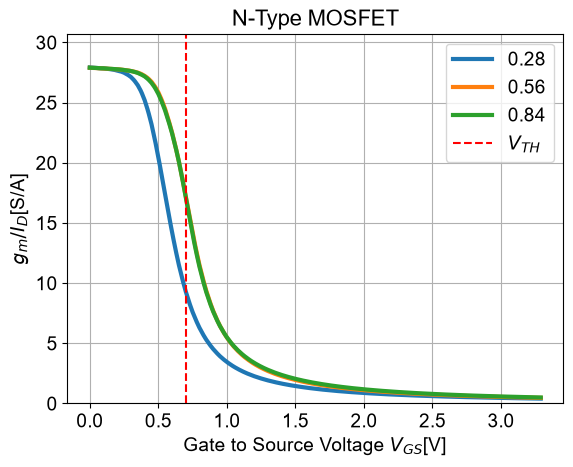

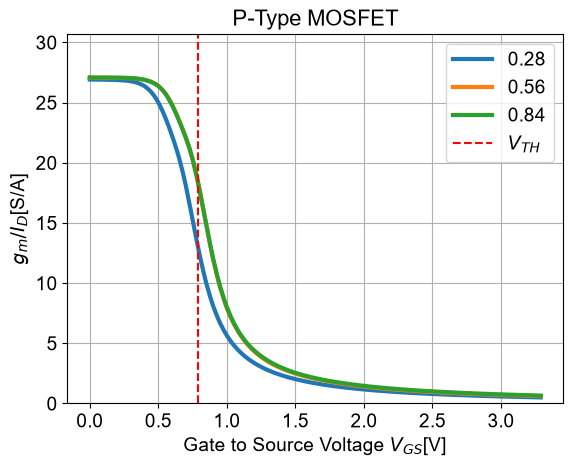

In [5]:
# Sweep VGS and find the corresponding gmID values for each VGS, at a given VDS, VSB and L.
VDS = max(nch['VDS'])
VSB = 0
LN = np.arange(min(nch['L']),3.1*min(nch['L']),min(nch['L']))
VGS = np.arange(0, VDS, 0.01)

gmIDN = nch.look_up('GM_ID', vgs=VGS, vds=VDS, vsb=VSB, L=LN)
VTHN = max(nch.look_up('VT', vgs=VDS/2, vds=VDS, vsb=VSB, L=LN)) # As a refrence of the threshold voltage.

plt.plot(VGS, np.transpose(gmIDN), linewidth = 3, label=np.round(LN, 2))
plt.axvline(x=VTHN, color='r', linestyle='--', label=r'$V_{TH}$')
plt.title(r'N-Type MOSFET', weight='normal',fontsize=16)
plt.xlabel(r'Gate to Source Voltage $V_{GS}$[V]',weight='normal',fontsize=14)
# Legend with L= values without using num2eng 
#plt.legend(LN,prop = { "size": 14 ,'weight':'normal'}, loc ="upper right")
plt.ylabel(r'$g_m/I_D$[S/A]', weight='normal',fontsize=14)
plt.xticks(weight='normal',fontsize=14);
plt.yticks(weight='normal',fontsize=14);
plt.legend(prop = { "size": 14 ,'weight':'normal'}, loc ="upper right")
plt.grid()
plt.ylim(0, max(gmIDN.flatten())*1.1)
plt.show()



LP = np.arange(min(nch['L']),3.1*min(nch['L']),min(nch['L']))

gmIDP = pch.look_up('GM_ID', vgs=VGS, vds=VDS, vsb=VSB, L=LP)
VTHP = max(pch.look_up('VT', vgs=VDS/2, vds=VDS, vsb=VSB, L=LP)) # As a refrence of the threshold voltage.

plt.plot(VGS, np.transpose(gmIDP), linewidth = 3, label=np.round(LP, 2))
plt.axvline(x=VTHP, color='r', linestyle='--', label=r'$V_{TH}$')
plt.title(r'P-Type MOSFET', weight='normal',fontsize=16)
plt.xlabel(r'Gate to Source Voltage $V_{GS}$[V]',weight='normal',fontsize=14)
# Legend with L= values without using num2eng 
#plt.legend(LN,prop = { "size": 14 ,'weight':'normal'}, loc ="upper right")
plt.ylabel(r'$g_m/I_D$[S/A]', weight='normal',fontsize=14)
plt.xticks(weight='normal',fontsize=14);
plt.yticks(weight='normal',fontsize=14);
plt.legend(prop = { "size": 14 ,'weight':'normal'}, loc ="upper right")
plt.grid()
plt.ylim(0, max(gmIDN.flatten())*1.1)
plt.show()

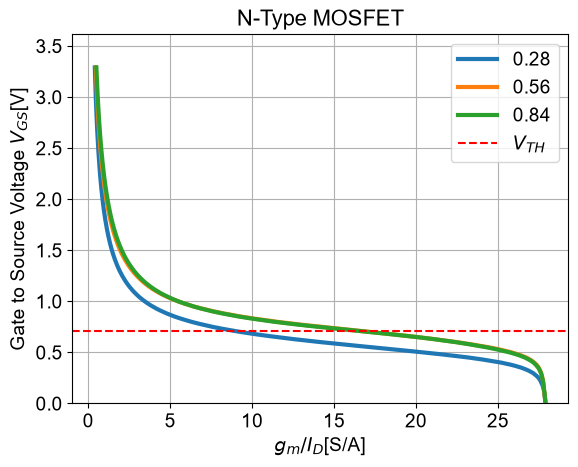

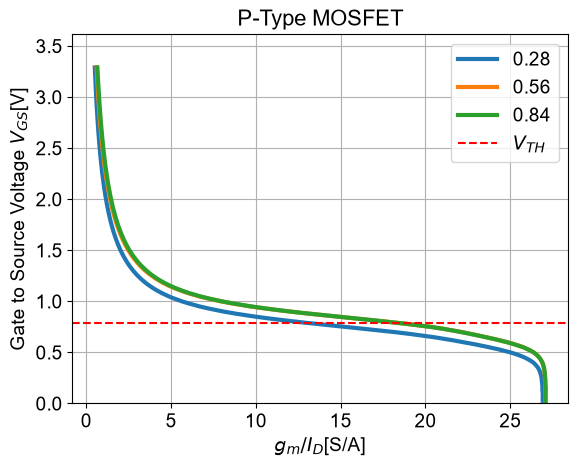

In [6]:
# Sweep VGS and find the corresponding gmID values for each VGS, at a given VDS, VSB and L.
VDS = max(nch['VDS'])
VSB = 0
LN = np.arange(min(nch['L']),3.1*min(nch['L']),min(nch['L']))
VGS = np.arange(0, VDS, 0.01)

gmIDN = nch.look_up('GM_ID', vgs=VGS, vds=VDS, vsb=VSB, L=LN)
VTHN = max(nch.look_up('VT', vgs=VDS/2, vds=VDS, vsb=VSB, L=LN)) # As a refrence of the threshold voltage.

plt.plot(np.transpose(gmIDN), VGS, linewidth = 3, label=np.round(LN, 2))
plt.axhline(y=VTHN, color='r', linestyle='--', label=r'$V_{TH}$')
plt.title(r'N-Type MOSFET', weight='normal',fontsize=16)
plt.ylabel(r'Gate to Source Voltage $V_{GS}$[V]',weight='normal',fontsize=14)
# Legend with L= values without using num2eng 
#plt.legend(LN,prop = { "size": 14 ,'weight':'normal'}, loc ="upper right")
plt.xlabel(r'$g_m/I_D$[S/A]', weight='normal',fontsize=14)
plt.xticks(weight='normal',fontsize=14);
plt.yticks(weight='normal',fontsize=14);
plt.legend(prop = { "size": 14 ,'weight':'normal'}, loc ="upper right")
plt.grid()
plt.ylim(0, max(VGS.flatten())*1.1)
plt.show()



LP = np.arange(min(nch['L']),3.1*min(nch['L']),min(nch['L']))

gmIDP = pch.look_up('GM_ID', vgs=VGS, vds=VDS, vsb=VSB, L=LP)
VTHP = max(pch.look_up('VT', vgs=VDS/2, vds=VDS, vsb=VSB, L=LP)) # As a refrence of the threshold voltage.

plt.plot(np.transpose(gmIDP), VGS, linewidth = 3, label=np.round(LP, 2))
plt.axhline(y=VTHP, color='r', linestyle='--', label=r'$V_{TH}$')
plt.title(r'P-Type MOSFET', weight='normal',fontsize=16)
plt.ylabel(r'Gate to Source Voltage $V_{GS}$[V]',weight='normal',fontsize=14)
# Legend with L= values without using num2eng 
#plt.legend(LN,prop = { "size": 14 ,'weight':'normal'}, loc ="upper right")
plt.xlabel(r'$g_m/I_D$[S/A]', weight='normal',fontsize=14)
plt.xticks(weight='normal',fontsize=14);
plt.yticks(weight='normal',fontsize=14);
plt.legend(prop = { "size": 14 ,'weight':'normal'}, loc ="upper right")
plt.grid()
plt.ylim(0, max(VGS.flatten())*1.1)
plt.show()

look_upVGS: GM_ID input larger than maximum!
look_upVGS: GM_ID input larger than maximum!
look_upVGS: GM_ID input larger than maximum!
look_upVGS: GM_ID input larger than maximum!
look_upVGS: GM_ID input larger than maximum!
look_upVGS: GM_ID input larger than maximum!


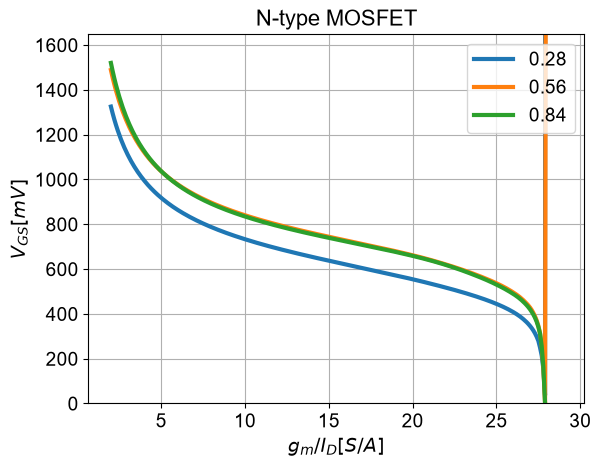

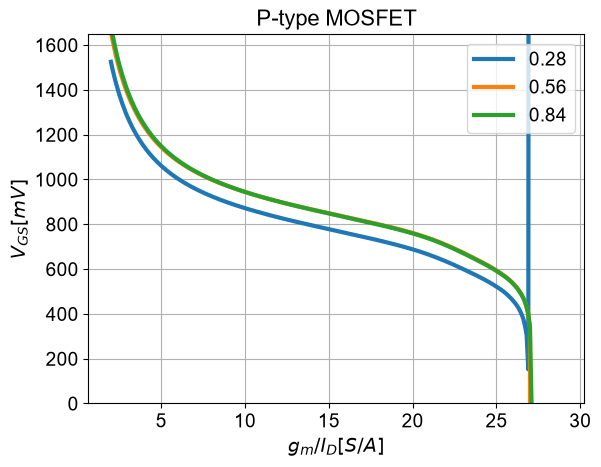

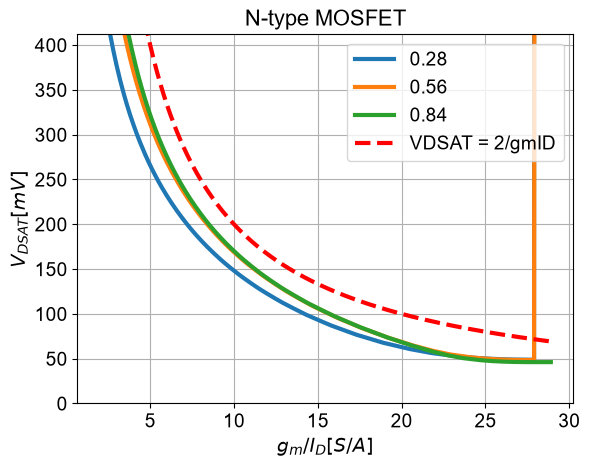

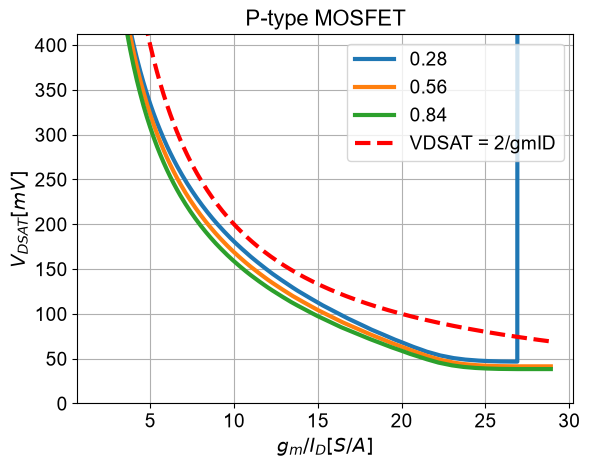

In [7]:
# If we need to find how it varies agains L we need to generate a loop to plot how VDSAT changes.
VDS = max(nch['VDS'])/2
VSB = 0
gmID = np.arange(2, 29, 0.1)
LN = np.arange(min(nch['L']),3.1*min(nch['L']),min(nch['L']))
LP = np.arange(min(pch['L']),3.1*min(pch['L']),min(pch['L']))

iVDSAT = 2/gmID

# Save the VGS values for each L in a list
VGSN = []
VDSatN = []
VGSP = []
VDSatP = []
for L in LN:
    tVGSN = nch.look_upVGS(GM_ID = gmID, vds = VDS, vsb = VSB, L = L)
    tVGSP = pch.look_upVGS(GM_ID = gmID, vds = VDS, vsb = VSB, L = L)
    VGSN.append(tVGSN)
    VGSP.append(tVGSP)
    tVDSATN = nch.look_up('VDSAT',vgs = tVGSN, vds=VDS, vsb=VSB, L=L)
    tVDSATP = pch.look_up('VDSAT',vgs = tVGSP, vds=VDS, vsb=VSB, L=L)
    VDSatN.append(tVDSATN)
    VDSatP.append(tVDSATP)


plt.plot(gmID, np.transpose(VGSN)*1e3, linewidth = 3)
plt.legend(np.round(LN, 2),prop = { "size": 14 ,'weight':'normal'}, loc ="upper right")
plt.title(r'N-type MOSFET', weight='normal',fontsize=16)
plt.xlabel(r'$g_m/I_D [S/A]$',weight='normal',fontsize=14)
plt.ylabel(r'$V_{GS} [mV]$', weight='normal',fontsize=14)
plt.xticks(weight='normal',fontsize=14)
plt.yticks(weight='normal',fontsize=14)
#plt.ylim(0, max(np.transpose(VGSN).flatten())*1.1*1e3)
plt.ylim(0, VDS*1e3)
plt.grid()
plt.show()

plt.plot(gmID, np.transpose(VGSP)*1e3, linewidth = 3);
plt.legend(np.round(LP, 2),prop = { "size": 14 ,'weight':'normal'}, loc ="upper right")
plt.title(r'P-type MOSFET', weight='normal',fontsize=16)
plt.xlabel(r'$g_m/I_D [S/A]$',weight='normal',fontsize=14)
plt.ylabel(r'$V_{GS} [mV]$', weight='normal',fontsize=14)
plt.xticks(weight='normal',fontsize=14)
plt.yticks(weight='normal',fontsize=14)
#plt.ylim(0, max(np.transpose(VGSN).flatten())*1.1*1e3)
plt.ylim(0, VDS*1e3)
plt.grid()
plt.show()



plt.plot(gmID, np.transpose(VDSatN)*1e3, linewidth = 3, label=np.round(LN, 2))
plt.plot(gmID, iVDSAT*1e3, linewidth = 3, linestyle='dashed', color='red', label='VDSAT = 2/gmID')
plt.legend(prop = { "size": 14 ,'weight':'normal'}, loc ="upper right")
plt.title(r'N-type MOSFET', weight='normal',fontsize=16)
plt.xlabel(r'$g_m/I_D [S/A]$',weight='normal',fontsize=14)
plt.ylabel(r'$V_{DSAT} [mV]$', weight='normal',fontsize=14)
plt.xticks(weight='normal',fontsize=14)
plt.yticks(weight='normal',fontsize=14)
#plt.ylim(0, max(np.transpose(VDSatN).flatten())*1.1*1e3)
plt.ylim(0, 0.25*VDS*1e3)
plt.grid()
plt.show()

plt.plot(gmID, np.transpose(VDSatP)*1e3, linewidth = 3, label=np.round(LP, 2))
plt.plot(gmID, iVDSAT*1e3, linewidth = 3, linestyle='dashed', color='red', label='VDSAT = 2/gmID')
plt.legend(prop = { "size": 14 ,'weight':'normal'}, loc ="upper right")
plt.title(r'P-type MOSFET', weight='normal',fontsize=16)
plt.xlabel(r'$g_m/I_D [S/A]$',weight='normal',fontsize=14)
plt.ylabel(r'$V_{DSAT} [mV]$', weight='normal',fontsize=14)
plt.xticks(weight='normal',fontsize=14)
plt.yticks(weight='normal',fontsize=14)
#plt.ylim(0, max(np.transpose(VDSatN).flatten())*1.1*1e3)
plt.ylim(0, 0.25*VDS*1e3)
plt.grid()
plt.show()


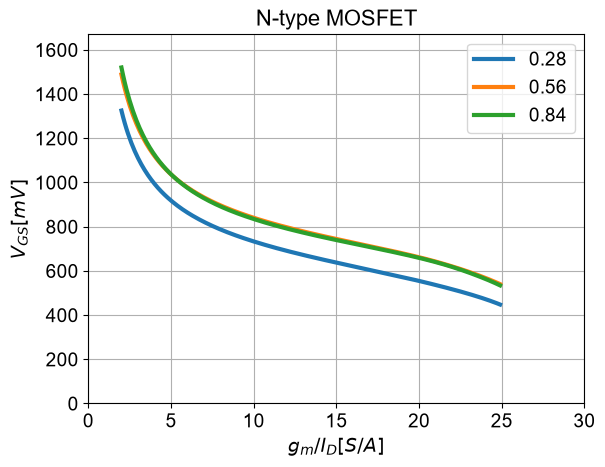

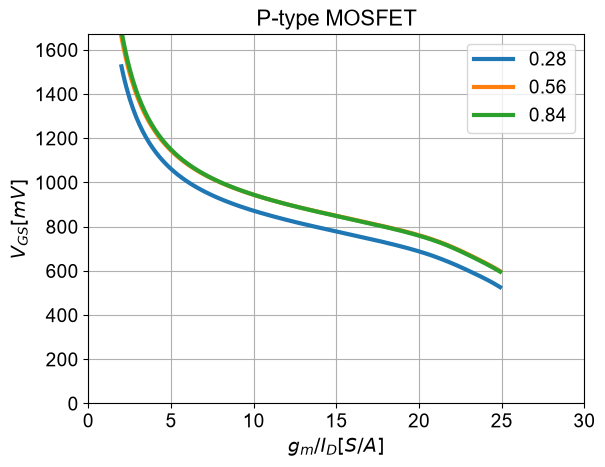

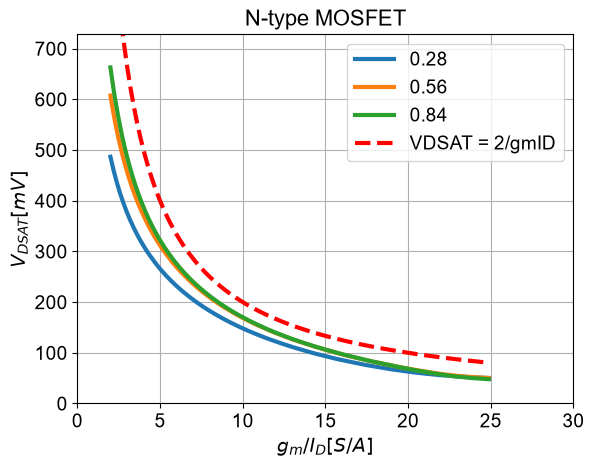

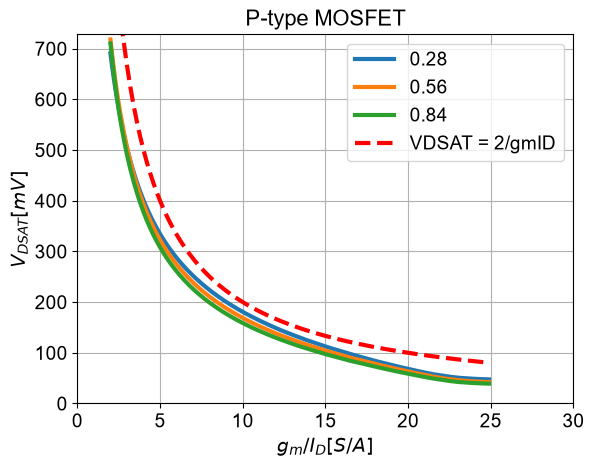

In [8]:
# Same plot but with working values for gmID NMOS and PMOS
# If we need to find how it varies agains L we need to generate a loop to plot how VDSAT changes.
VDS = max(nch['VDS'])/2
VSB = 0
gmIDN = np.arange(2, 25, 0.1)
gmIDP = np.arange(2, 25, 0.1)
LN = np.arange(min(nch['L']),3.1*min(nch['L']),min(nch['L']))
LP = np.arange(min(pch['L']),3.1*min(pch['L']),min(pch['L']))

iVDSATN = 2/gmIDN
iVDSATP = 2/gmIDP

# Save the VGS values for each L in a list
VGSN = []
VDSatN = []
VGSP = []
VDSatP = []
for L in LN:
    tVGSN = nch.look_upVGS(GM_ID = gmIDN, vds = VDS, vsb = VSB, L = L)
    tVGSP = pch.look_upVGS(GM_ID = gmIDP, vds = VDS, vsb = VSB, L = L)
    VGSN.append(tVGSN)
    VGSP.append(tVGSP)
    tVDSATN = nch.look_up('VDSAT',vgs = tVGSN, vds=VDS, vsb=VSB, L=L)
    tVDSATP = pch.look_up('VDSAT',vgs = tVGSP, vds=VDS, vsb=VSB, L=L)
    VDSatN.append(tVDSATN)
    VDSatP.append(tVDSATP)


plt.plot(gmIDN, np.transpose(VGSN)*1e3, linewidth = 3)
plt.legend(np.round(LN, 2),prop = { "size": 14 ,'weight':'normal'}, loc ="upper right")
plt.title(r'N-type MOSFET', weight='normal',fontsize=16)
plt.xlabel(r'$g_m/I_D [S/A]$',weight='normal',fontsize=14)
plt.ylabel(r'$V_{GS} [mV]$', weight='normal',fontsize=14)
plt.xticks(weight='normal',fontsize=14)
plt.yticks(weight='normal',fontsize=14)
plt.ylim(0, max(np.transpose(VGSN).flatten())*1.1*1e3)
plt.xlim(0, 30)
plt.grid()
plt.show()

plt.plot(gmIDP, np.transpose(VGSP)*1e3, linewidth = 3);
plt.legend(np.round(LP, 2),prop = { "size": 14 ,'weight':'normal'}, loc ="upper right")
plt.title(r'P-type MOSFET', weight='normal',fontsize=16)
plt.xlabel(r'$g_m/I_D [S/A]$',weight='normal',fontsize=14)
plt.ylabel(r'$V_{GS} [mV]$', weight='normal',fontsize=14)
plt.xticks(weight='normal',fontsize=14)
plt.yticks(weight='normal',fontsize=14)
plt.ylim(0, max(np.transpose(VGSN).flatten())*1.1*1e3)
plt.xlim(0, 30)
plt.grid()
plt.show()



plt.plot(gmIDN, np.transpose(VDSatN)*1e3, linewidth = 3, label=np.round(LN, 2))
plt.plot(gmIDN, iVDSATN*1e3, linewidth = 3, linestyle='dashed', color='red', label='VDSAT = 2/gmID')
plt.legend(prop = { "size": 14 ,'weight':'normal'}, loc ="upper right")
plt.title(r'N-type MOSFET', weight='normal',fontsize=16)
plt.xlabel(r'$g_m/I_D [S/A]$',weight='normal',fontsize=14)
plt.ylabel(r'$V_{DSAT} [mV]$', weight='normal',fontsize=14)
plt.xticks(weight='normal',fontsize=14)
plt.yticks(weight='normal',fontsize=14)
plt.ylim(0, max(np.transpose(VDSatN).flatten())*1.1*1e3)
plt.xlim(0, 30)
plt.grid()
plt.show()

plt.plot(gmIDP, np.transpose(VDSatP)*1e3, linewidth = 3, label=np.round(LP, 2))
plt.plot(gmIDP, iVDSATP*1e3, linewidth = 3, linestyle='dashed', color='red', label='VDSAT = 2/gmID')
plt.legend(prop = { "size": 14 ,'weight':'normal'}, loc ="upper right")
plt.title(r'P-type MOSFET', weight='normal',fontsize=16)
plt.xlabel(r'$g_m/I_D [S/A]$',weight='normal',fontsize=14)
plt.ylabel(r'$V_{DSAT} [mV]$', weight='normal',fontsize=14)
plt.xticks(weight='normal',fontsize=14)
plt.yticks(weight='normal',fontsize=14)
plt.ylim(0, max(np.transpose(VDSatN).flatten())*1.1*1e3)
plt.xlim(0, 30)
plt.grid()
plt.show()


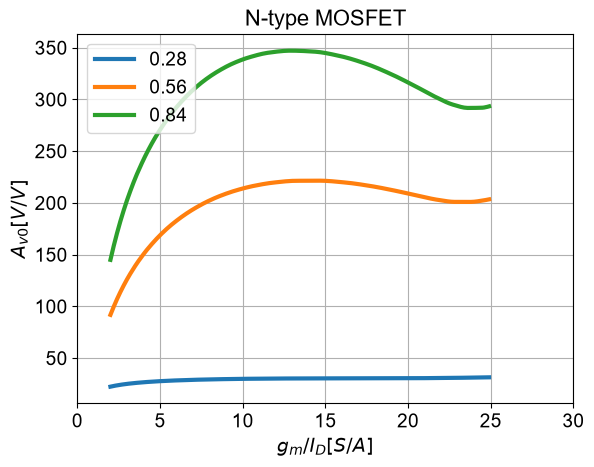

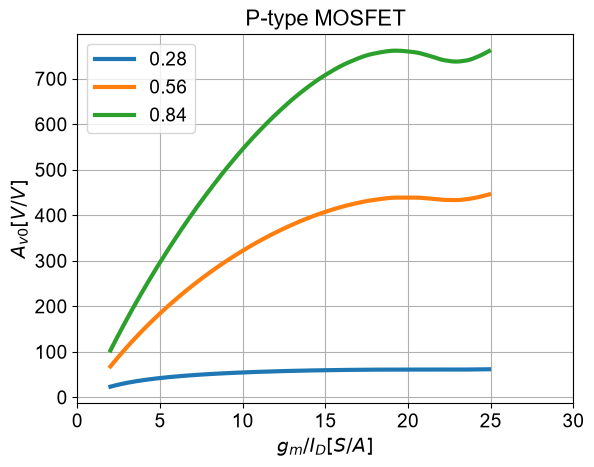

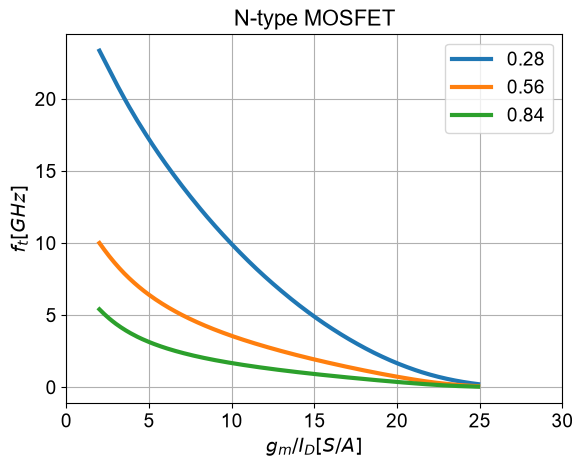

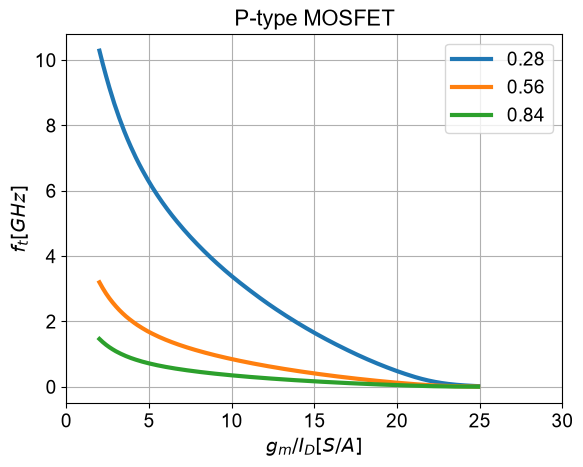

In [9]:
#Plot gmID vs av0 and ft for varying L, at a given VDS and VSB.
VDS = max(nch['VDS'])/2
VSB = 0
gmIDN = np.arange(2, 25, 0.1)
gmIDP = np.arange(2, 25, 0.1)
LN = np.arange(min(nch['L']),3.1*min(nch['L']),min(nch['L']))
LP = np.arange(min(pch['L']),3.1*min(pch['L']),min(pch['L']))
ftN = nch.look_up('GM_CGG', GM_ID=gmIDN, vds=VDS, vsb=VSB, L=LN)/2/np.pi
av0N = nch.look_up('GM_GDS', GM_ID=gmIDN, vds=VDS, vsb=VSB, L=LN)
ftP = pch.look_up('GM_CGG', GM_ID=gmIDP, vds=VDS, vsb=VSB, L=LP)/2/np.pi
av0P = pch.look_up('GM_GDS', GM_ID=gmIDP, vds=VDS, vsb=VSB, L=LP)

plt.plot(gmIDN, np.transpose(av0N), linewidth = 3)
plt.legend(np.round(LN, 2),prop = { "size": 14 ,'weight':'normal'}, loc ="upper left")
plt.title('N-type MOSFET', weight='normal',fontsize=16)
plt.xlabel(r'$g_m/I_D [S/A]$',weight='normal',fontsize=14)
plt.ylabel(r'$A_{v0} [V/V]$', weight='normal',fontsize=14)
plt.xticks(weight='normal',fontsize=14)
plt.yticks(weight='normal',fontsize=14)
plt.xlim(0, 30)
plt.grid()
plt.show()

plt.plot(gmIDP, np.transpose(av0P), linewidth = 3)
plt.legend(np.round(LP, 2),prop = { "size": 14 ,'weight':'normal'}, loc ="upper left")
plt.title('P-type MOSFET', weight='normal',fontsize=16)
plt.xlabel(r'$g_m/I_D [S/A]$',weight='normal',fontsize=14)
plt.ylabel(r'$A_{v0} [V/V]$', weight='normal',fontsize=14)
plt.xticks(weight='normal',fontsize=14)
plt.yticks(weight='normal',fontsize=14)
plt.xlim(0, 30)
plt.grid()
plt.show()

plt.plot(gmIDN, np.transpose(ftN)*1e-9, linewidth = 3);
plt.legend(np.round(LN, 2),prop = { "size": 14 ,'weight':'normal'}, loc ="upper right")
plt.title('N-type MOSFET', weight='normal',fontsize=16)
plt.xlabel(r'$g_m/I_D [S/A]$',weight='normal',fontsize=14)
plt.ylabel(r'$f_{t} [GHz]$', weight='normal',fontsize=14)
plt.xticks(weight='normal',fontsize=14)
plt.yticks(weight='normal',fontsize=14)
plt.xlim(0, 30)
plt.grid()
plt.show()

plt.plot(gmIDP, np.transpose(ftP)*1e-9, linewidth = 3);
plt.legend(np.round(LP, 2),prop = { "size": 14 ,'weight':'normal'}, loc ="upper right")
plt.title('P-type MOSFET', weight='normal',fontsize=16)
plt.xlabel(r'$g_m/I_D [S/A]$',weight='normal',fontsize=14)
plt.ylabel(r'$f_{t} [GHz]$', weight='normal',fontsize=14)
plt.xticks(weight='normal',fontsize=14)
plt.yticks(weight='normal',fontsize=14)
plt.xlim(0, 30)
plt.grid()
plt.show()

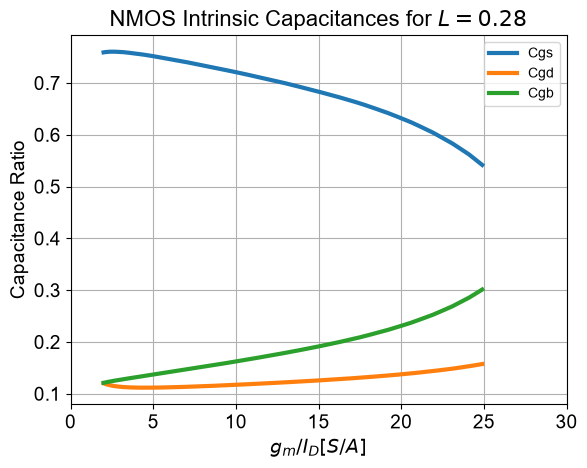

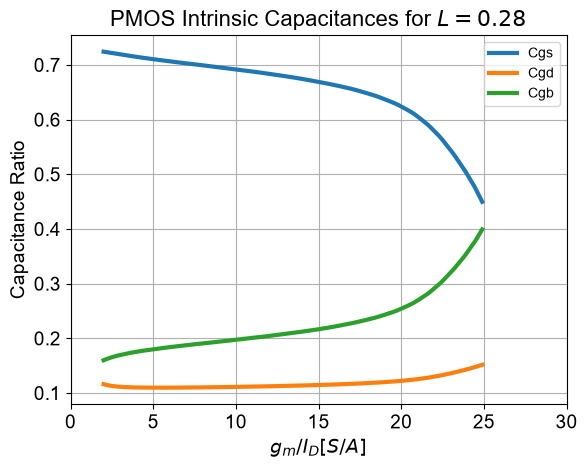

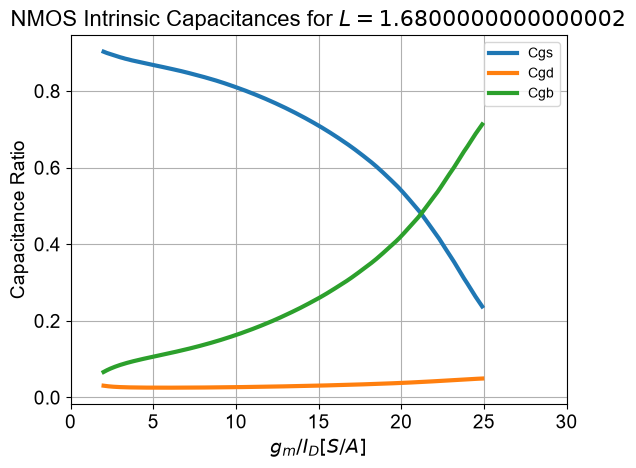

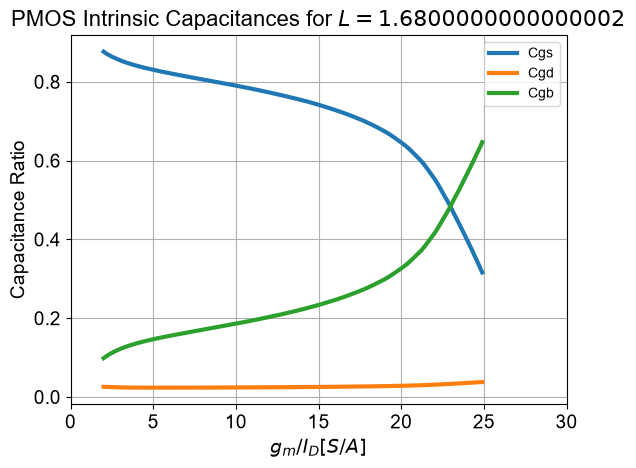

In [10]:
# Intrinsic Capacitances
VDS = max(nch['VDS'])/2
VSB = 0
gmIDN = np.arange(2, 25, 0.1)
gmIDP = np.arange(2, 25, 0.1)
LN = 1*min(nch['L'])
LP = 1*min(pch['L'])

cggIDN = nch.look_up('CGG_ID', GM_ID=gmIDN, vds=VDS, vsb=VSB, L=LN)
cgsIDN = nch.look_up('CGS_ID', GM_ID=gmIDN, vds=VDS, vsb=VSB, L=LN)
cgdIDN = nch.look_up('CGD_ID', GM_ID=gmIDN, vds=VDS, vsb=VSB, L=LN)
cgbIDN = nch.look_up('CGB_ID', GM_ID=gmIDN, vds=VDS, vsb=VSB, L=LN)

cggIDP = pch.look_up('CGG_ID', GM_ID=gmIDP, vds=VDS, vsb=VSB, L=LP)
cgsIDP = pch.look_up('CGS_ID', GM_ID=gmIDP, vds=VDS, vsb=VSB, L=LP)
cgdIDP = pch.look_up('CGD_ID', GM_ID=gmIDP, vds=VDS, vsb=VSB, L=LP)
cgbIDP = pch.look_up('CGB_ID', GM_ID=gmIDP, vds=VDS, vsb=VSB, L=LP)

# To better understand the values we are going to normalize the capacitances by cggID
plt.plot(gmIDN, np.transpose(cgsIDN/cggIDN), linewidth = 3, label='Cgs')
plt.plot(gmIDN, np.transpose(cgdIDN/cggIDN), linewidth = 3, label='Cgd')
plt.plot(gmIDN, np.transpose(cgbIDN/cggIDN), linewidth = 3, label='Cgb')
plt.title(r'NMOS Intrinsic Capacitances for $L=' + str(LN) + r'$', weight='normal',fontsize=16)
plt.xlabel(r'$g_m/I_D [S/A]$',weight='normal',fontsize=14)
plt.ylabel(r'Capacitance Ratio', weight='normal',fontsize=14)
plt.legend()
plt.xticks(weight='normal',fontsize=14)
plt.yticks(weight='normal',fontsize=14)
plt.xlim(0, 30)
plt.grid()
plt.show()


plt.plot(gmIDP, np.transpose(cgsIDP/cggIDP), linewidth = 3, label='Cgs')
plt.plot(gmIDP, np.transpose(cgdIDP/cggIDP), linewidth = 3, label='Cgd')
plt.plot(gmIDP, np.transpose(cgbIDP/cggIDP), linewidth = 3, label='Cgb')
plt.title(r'PMOS Intrinsic Capacitances for $L=' + str(LP) + r'$', weight='normal',fontsize=16)
plt.xlabel(r'$g_m/I_D [S/A]$',weight='normal',fontsize=14)
plt.ylabel(r'Capacitance Ratio', weight='normal',fontsize=14)
plt.legend()
plt.xticks(weight='normal',fontsize=14)
plt.yticks(weight='normal',fontsize=14)
plt.xlim(0, 30)
plt.grid()
plt.show()


LN = 6*min(nch['L'])
LP = 6*min(pch['L'])
cggIDN = nch.look_up('CGG_ID', GM_ID=gmIDN, vds=VDS, vsb=VSB, L=LN)
cgsIDN = nch.look_up('CGS_ID', GM_ID=gmIDN, vds=VDS, vsb=VSB, L=LN)
cgdIDN = nch.look_up('CGD_ID', GM_ID=gmIDN, vds=VDS, vsb=VSB, L=LN)
cgbIDN = nch.look_up('CGB_ID', GM_ID=gmIDN, vds=VDS, vsb=VSB, L=LN)

cggIDP = pch.look_up('CGG_ID', GM_ID=gmIDP, vds=VDS, vsb=VSB, L=LP)
cgsIDP = pch.look_up('CGS_ID', GM_ID=gmIDP, vds=VDS, vsb=VSB, L=LP)
cgdIDP = pch.look_up('CGD_ID', GM_ID=gmIDP, vds=VDS, vsb=VSB, L=LP)
cgbIDP = pch.look_up('CGB_ID', GM_ID=gmIDP, vds=VDS, vsb=VSB, L=LP)

# To better understand the values we are going to normalize the capacitances by cggID
plt.plot(gmIDN, np.transpose(cgsIDN/cggIDN), linewidth = 3, label='Cgs')
plt.plot(gmIDN, np.transpose(cgdIDN/cggIDN), linewidth = 3, label='Cgd')
plt.plot(gmIDN, np.transpose(cgbIDN/cggIDN), linewidth = 3, label='Cgb')
plt.title(r'NMOS Intrinsic Capacitances for $L=' + str(LN) + r'$', weight='normal',fontsize=16)
plt.xlabel(r'$g_m/I_D [S/A]$',weight='normal',fontsize=14)
plt.ylabel(r'Capacitance Ratio', weight='normal',fontsize=14)
plt.legend()
plt.xticks(weight='normal',fontsize=14)
plt.yticks(weight='normal',fontsize=14)
plt.xlim(0, 30)
plt.grid()
plt.show()

plt.plot(gmIDP, np.transpose(cgsIDP/cggIDP), linewidth = 3, label='Cgs')
plt.plot(gmIDP, np.transpose(cgdIDP/cggIDP), linewidth = 3, label='Cgd')
plt.plot(gmIDP, np.transpose(cgbIDP/cggIDP), linewidth = 3, label='Cgb')
plt.title(r'PMOS Intrinsic Capacitances for $L=' + str(LP) + r'$', weight='normal',fontsize=16)
plt.xlabel(r'$g_m/I_D [S/A]$',weight='normal',fontsize=14)
plt.ylabel(r'Capacitance Ratio', weight='normal',fontsize=14)
plt.legend()
plt.xticks(weight='normal',fontsize=14)
plt.yticks(weight='normal',fontsize=14)
plt.xlim(0, 30)
plt.grid()
plt.show()


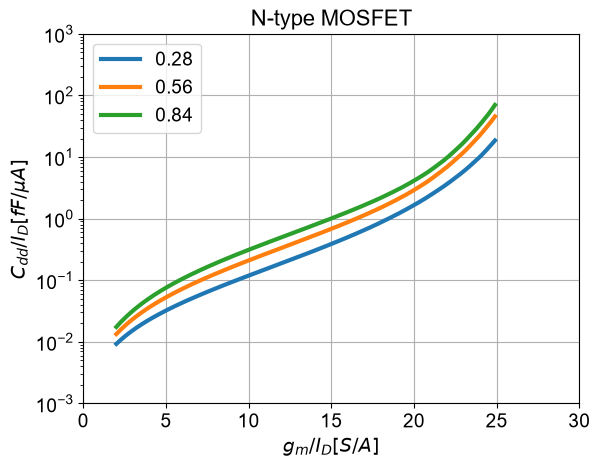

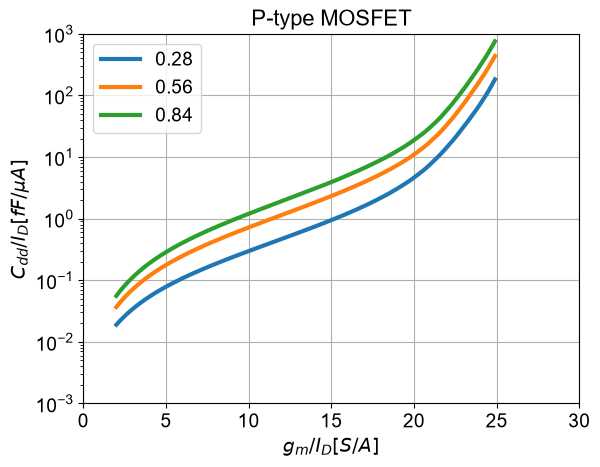

In [11]:
#Plot gmID vs cddID for varying L, at a given VDS and VSB.
VDS = max(nch['VDS'])/2
VSB = 0
gmIDN = np.arange(2, 25, 0.1)
gmIDP = np.arange(2, 25, 0.1)
LN = np.arange(min(nch['L']),3.1*min(nch['L']),min(nch['L']))
LP = np.arange(min(pch['L']),3.1*min(pch['L']),min(pch['L']))


cddIDN = nch.look_up('CDD_ID', GM_ID=gmIDN, vds=VDS, vsb=VSB, L=LN)
cddIDP = pch.look_up('CDD_ID', GM_ID=gmIDP, vds=VDS, vsb=VSB, L=LP)

plt.semilogy(gmIDN, np.transpose(cddIDN)*1e9, linewidth = 3, label='NMOS');
plt.legend(np.round(LN,2),prop = { "size": 14 ,'weight':'normal'}, loc ="upper left")
plt.title('N-type MOSFET', weight='normal',fontsize=16)
plt.xlabel(r'$g_m/I_D [S/A]$',weight='normal',fontsize=14);
plt.ylabel(r'$C_{dd}/I_D [fF/\mu A]$', weight='normal',fontsize=14);
plt.xticks(weight='normal',fontsize=14)
#ytickslabel = [1e-12, 1e-11, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6]
#plt.yticks(ytickslabel,[num2eng(x) for x in ytickslabel], weight='normal',fontsize=14);
plt.yticks(weight='normal',fontsize=14)
plt.xlim(0, 30)
plt.ylim(1e-3, 1e3)
plt.grid()
plt.show()


plt.semilogy(gmIDP, np.transpose(cddIDP)*1e9, linewidth = 3, label='PMOS');
plt.legend(np.round(LP, 2),prop = { "size": 14 ,'weight':'normal'}, loc ="upper left")
plt.title('P-type MOSFET', weight='normal',fontsize=16)
plt.xlabel(r'$g_m/I_D [S/A]$',weight='normal',fontsize=14);
plt.ylabel(r'$C_{dd}/I_D [fF/\mu A]$', weight='normal',fontsize=14);
plt.xticks(weight='normal',fontsize=14)
#ytickslabel = [1e-12, 1e-11, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6]
#plt.yticks(ytickslabel,[num2eng(x) for x in ytickslabel], weight='normal',fontsize=14);
plt.yticks(weight='normal',fontsize=14)
plt.xlim(0, 30)
plt.ylim(1e-3, 1e3)
plt.grid()
plt.show()


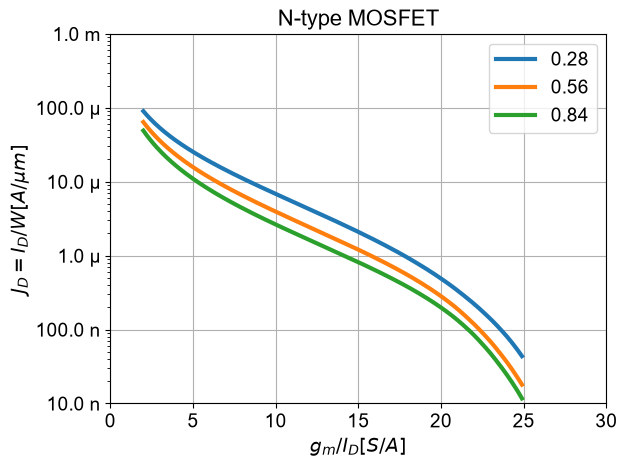

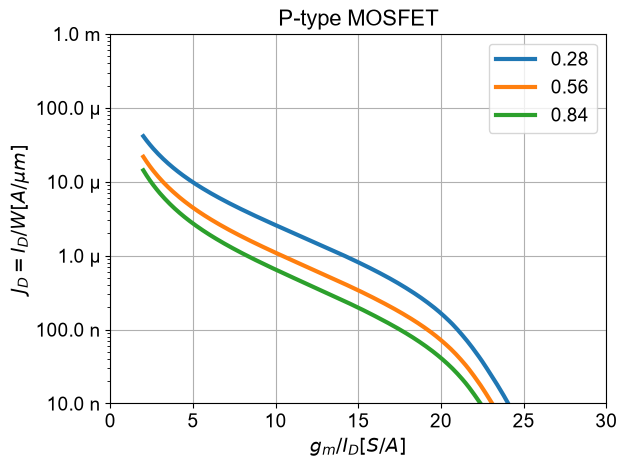

In [13]:
#Plot gmID vs cddID for varying L, at a given VDS and VSB.
VDS = max(nch['VDS'])/2
VSB = 0
gmIDN = np.arange(2, 25, 0.1)
gmIDP = np.arange(2, 25, 0.1)
LN = np.arange(min(nch['L']),3.1*min(nch['L']),min(nch['L']))
LP = np.arange(min(pch['L']),3.1*min(pch['L']),min(pch['L']))


JDN = nch.look_up('ID_W', GM_ID=gmIDN, vds=VDS, vsb=VSB, L=LN)
JDP = pch.look_up('ID_W', GM_ID=gmIDP, vds=VDS, vsb=VSB, L=LP)

plt.semilogy(gmIDN, np.transpose(JDN), linewidth = 3, label='NMOS');
plt.legend(np.round(LN, 2),prop = { "size": 14 ,'weight':'normal'}, loc ="upper right")
plt.title('N-type MOSFET', weight='normal',fontsize=16)
plt.xlabel(r'$g_m/I_D [S/A]$',weight='normal',fontsize=14);
plt.ylabel(r'$J_D=I_{D}/W [A/\mu m]$', weight='normal',fontsize=14);
plt.xticks(weight='normal',fontsize=14)
ytickslabel = [1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3]
plt.yticks(ytickslabel,[num2eng(x) for x in ytickslabel], weight='normal',fontsize=14);
plt.xlim(0, 30)
plt.ylim(1e-8, 1e-3)
plt.grid()
plt.show()


plt.semilogy(gmIDP, np.transpose(JDP), linewidth = 3, label='PMOS');
plt.legend(np.round(LP, 2),prop = { "size": 14 ,'weight':'normal'}, loc ="upper right")
plt.title('P-type MOSFET', weight='normal',fontsize=16)
plt.xlabel(r'$g_m/I_D [S/A]$',weight='normal',fontsize=14);
plt.ylabel(r'$J_D=I_{D}/W [A/\mu m]$', weight='normal',fontsize=14);
plt.xticks(weight='normal',fontsize=14)
ytickslabel = [1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3]
plt.yticks(ytickslabel,[num2eng(x) for x in ytickslabel], weight='normal',fontsize=14);
plt.xlim(0, 30)
plt.ylim(1e-8, 1e-3)
plt.grid()
plt.show()


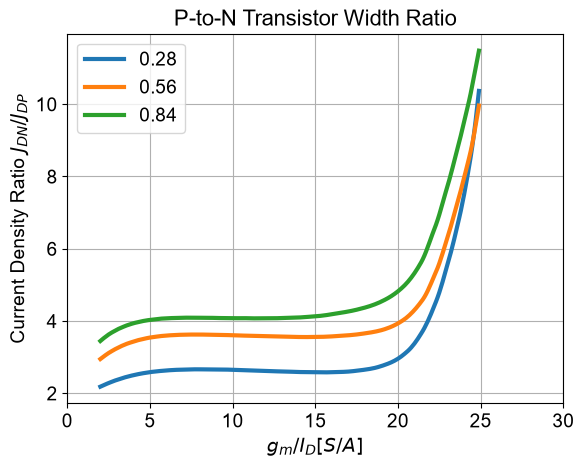

In [15]:
#Plot gmID vs cddID for varying L, at a given VDS and VSB.
VDS = max(nch['VDS'])/2
VSB = 0
gmIDN = np.arange(2, 25, 0.1)
gmIDP = np.arange(2, 25, 0.1)
LN = np.arange(min(nch['L']),3.1*min(nch['L']),min(nch['L']))
LP = np.arange(min(pch['L']),3.1*min(pch['L']),min(pch['L']))


JDN = nch.look_up('ID_W', GM_ID=gmIDN, vds=VDS, vsb=VSB, L=LN)
JDP = pch.look_up('ID_W', GM_ID=gmIDP, vds=VDS, vsb=VSB, L=LP)


plt.plot(gmIDN, np.transpose(JDN/JDP), linewidth = 3, label='NMOS');
plt.legend(np.round(LN, 2),prop = { "size": 14 ,'weight':'normal'}, loc ="upper left")
plt.title('P-to-N Transistor Width Ratio', weight='normal',fontsize=16)
plt.xlabel(r'$g_m/I_D [S/A]$',weight='normal',fontsize=14);
plt.ylabel(r'Current Density Ratio $J_{DN}/J_{DP}$', weight='normal',fontsize=14);
plt.xticks(weight='normal',fontsize=14)
ytickslabel = [1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3]
plt.yticks(weight='normal',fontsize=14)
plt.xlim(0, 30)
plt.grid()
plt.show()



Design of a IGS with 
Av = 50
Fu = 1GHz
CL = 200fF

In [16]:
fu = 1e9 #frequency in Hz
CL = 200e-15 #load capacitance in F
Av = 100 #voltage gain
VDD = max(nch['VDS']) #supply voltage in V

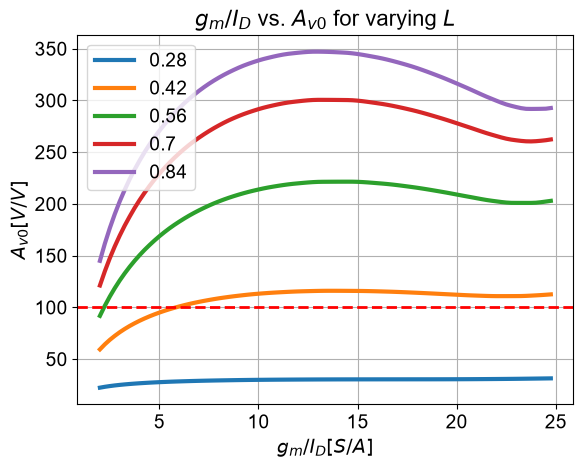

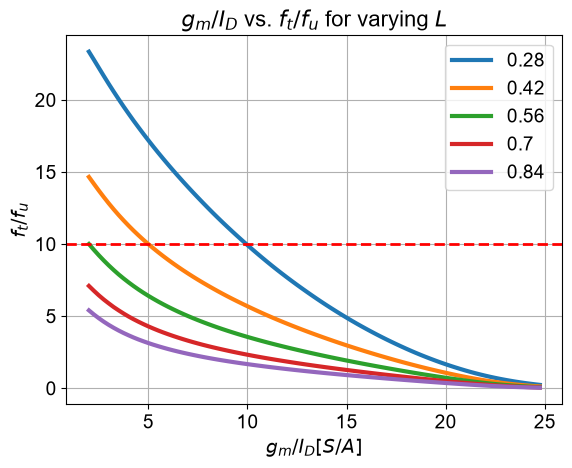

In [17]:
#Plot gmID vs av0 and ft for varying L, at a given VDS and VSB.
VDS = max(nch['VDS'])/2
VSB = 0
gmID = np.arange(2, 25, 0.25)
LN = np.arange(min(nch['L']),3.1*min(nch['L']),min(nch['L'])/2)

ft = nch.look_up('GM_CGG', GM_ID=gmID, vds=VDS, vsb=VSB, L=LN)/2/np.pi
av0 = nch.look_up('GM_GDS', GM_ID=gmID, vds=VDS, vsb=VSB, L=LN)

plt.plot(gmID, np.transpose(av0), linewidth = 3)
plt.axhline(y=Av, color='r', linestyle='--', linewidth = 2)
plt.legend(np.round(LN, 2),prop = { "size": 14 ,'weight':'normal'}, loc ="upper left")
plt.title(r'$g_m/I_D$ vs. $A_{v0}$ for varying $L$', weight='normal',fontsize=16)
plt.xlabel(r'$g_m/I_D [S/A]$',weight='normal',fontsize=14);
plt.ylabel(r'$A_{v0} [V/V]$', weight='normal',fontsize=14);
plt.xticks(weight='normal',fontsize=14);
plt.yticks(weight='normal',fontsize=14);
plt.grid()
plt.show()

plt.plot(gmID, np.transpose(ft/fu), linewidth = 3);
plt.axhline(y=10, color='r', linestyle='--', linewidth = 2)
plt.legend(np.round(LN, 2),prop = { "size": 14 ,'weight':'normal'}, loc ="upper right")
plt.title(r'$g_m/I_D$ vs. $f_{t}/f_u$ for varying $L$', weight='normal',fontsize=16)
plt.xlabel(r'$g_m/I_D [S/A]$',weight='normal',fontsize=14);
plt.ylabel(r'$f_{t}/f_u$', weight='normal',fontsize=14);
plt.xticks(weight='normal',fontsize=14);
plt.yticks(weight='normal',fontsize=14);
plt.grid()
plt.show()


In [18]:
VDS = max(nch['VDS'])/2
VSB = 0
gmID = 6
LN = 0.42

ft = nch.look_up('GM_CGG', GM_ID=gmID, vds=VDS, vsb=VSB, L=LN)/2/np.pi
av0 = nch.look_up('GM_GDS', GM_ID=gmID, vds=VDS, vsb=VSB, L=LN)
av0dB = 20*np.log10(av0)

print(f'For gmID = {gmID} S/A and L = {LN} um, ft/fu = {num2eng(ft/fu)}')
print(f'Av0 = {num2eng(av0)} V/V or {num2eng(av0dB)} dB')

For gmID = 6 S/A and L = 0.42 um, ft/fu = 8.9 
Av0 = 100.8  V/V or 40.1  dB


In [19]:
VDS = max(nch['VDS'])/2
VSB = 0
gmID = 6
LN = 0.42

VGS = nch.look_upVGS(GM_ID=gmID, vds=VDS, vsb=VSB, L=LN)
VDSat = nch.look_up('VDSAT', vgs=VGS, vds=VDS, vsb=VSB, L=LN)
JD = nch.look_up('ID_W', GM_ID=gmID, vds=VDS, vsb=VSB, L=LN)
cddID = nch.look_up('CDD_ID', GM_ID=gmID, vds=VDS, vsb=VSB, L=LN)

print(f'VGS = {num2eng(float(VGS))} V, VDSat = {num2eng(float(VDSat))} V')
print(f'JD = {num2eng(float(JD))} A/um, Cdd/ID = {num2eng(float(cddID))} F/A')


VGS = 956.3 m V, VDSat = 257.8 m V
JD = 14.4 µ A/um, Cdd/ID = 58.2 p F/A


In [20]:
Cdd = 0
niter = 5
CLtot = CL + Cdd
for i in range(niter):
    gm = 2*np.pi*fu*CLtot
    ID = gm/gmID
    W = ID/JD
    Cdd = cddID*ID
    CLtot = CL + Cdd
    print(f'Iteration {i+1}: gm = {num2eng(float(gm))} S, ID = {num2eng(float(ID))} A, W = {num2eng(float(W))} m, Cdd = {num2eng(float(Cdd))} F, CLtot = {num2eng(float(CLtot))} F')

Iteration 1: gm = 1.3 m S, ID = 209.4 µ A, W = 14.5  m, Cdd = 12.2 f F, CLtot = 212.2 f F
Iteration 2: gm = 1.3 m S, ID = 222.2 µ A, W = 15.4  m, Cdd = 12.9 f F, CLtot = 212.9 f F
Iteration 3: gm = 1.3 m S, ID = 223.0 µ A, W = 15.5  m, Cdd = 13.0 f F, CLtot = 213.0 f F
Iteration 4: gm = 1.3 m S, ID = 223.0 µ A, W = 15.5  m, Cdd = 13.0 f F, CLtot = 213.0 f F
Iteration 5: gm = 1.3 m S, ID = 223.0 µ A, W = 15.5  m, Cdd = 13.0 f F, CLtot = 213.0 f F


In [21]:
# print the gmID parameters, gmID, L, VDS, VSB, ft/fu, av0, VGS, VDSAT, ID, CDD, W, gm using a pretty table
table = PrettyTable()
table.field_names = ["Parameter", "Value"]
table.add_row(["gmID", num2eng(float(gmID)) + " S/A"])
table.add_row(["L", str(LN) + " um"])
table.add_row(["VDS", num2eng(float(VDS)) + " V"])
table.add_row(["VSB", num2eng(float(VSB)) + " V"])
table.add_row(["ft/fu", num2eng(float(ft/fu))])
table.add_row(["Av0", num2eng(float(av0)) + " V/V "])
table.add_row(["Av0 (dB)", num2eng(float(av0dB)) + " dB"])
table.add_row(["VGS", num2eng(float(VGS)) + " V"])
table.add_row(["VDSAT", num2eng(float(VDSat)) + " V"])
table.add_row(["ID", num2eng(float(ID)) + " A"])
table.add_row(["CDD", num2eng(float(Cdd)) + " F"])
table.add_row(["W", num2eng(float(W)) + " um"])
table.add_row(["gm", num2eng(float(gm)) + " S"])
print(table)


+-----------+-------------+
| Parameter |    Value    |
+-----------+-------------+
|    gmID   |   6.0  S/A  |
|     L     |   0.42 um   |
|    VDS    |    1.6  V   |
|    VSB    |    0.0  V   |
|   ft/fu   |     8.9     |
|    Av0    | 100.8  V/V  |
|  Av0 (dB) |   40.1  dB  |
|    VGS    |  956.3 m V  |
|   VDSAT   |  257.8 m V  |
|     ID    |  223.0 µ A  |
|    CDD    |   13.0 f F  |
|     W     |   15.5  um  |
|     gm    |   1.3 m S   |
+-----------+-------------+


Generate the same excercise for:


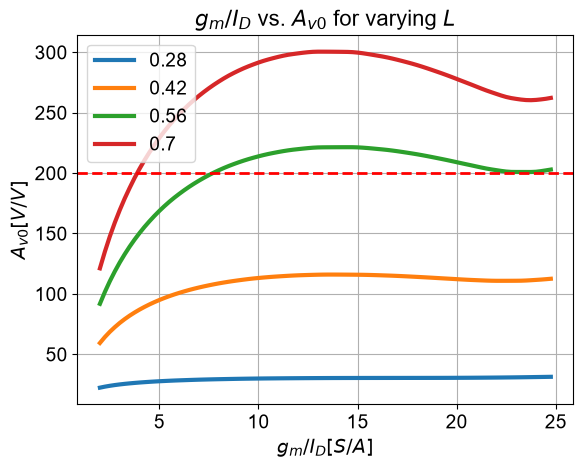

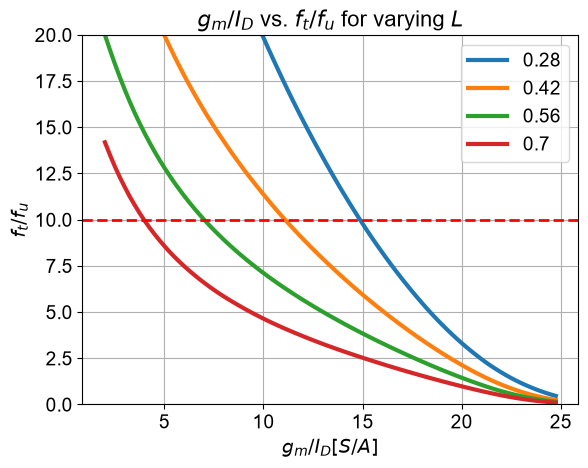

In [22]:
fu = 500e6 #frequency in Hz
CL = 200e-15 #load capacitance in F
Av = 200 #voltage gain
VDD = max(nch['VDS']) #supply voltage in V

#Plot gmID vs av0 and ft for varying L, at a given VDS and VSB.
VDS = max(nch['VDS'])/2
VSB = 0
gmID = np.arange(2, 25, 0.25)
LN = np.arange(min(nch['L']),3*min(nch['L']),min(nch['L'])/2)

ft = nch.look_up('GM_CGG', GM_ID=gmID, vds=VDS, vsb=VSB, L=LN)/2/np.pi
av0 = nch.look_up('GM_GDS', GM_ID=gmID, vds=VDS, vsb=VSB, L=LN)

plt.plot(gmID, np.transpose(av0), linewidth = 3)
plt.axhline(y=Av, color='r', linestyle='--', linewidth = 2)
plt.legend(np.round(LN, 2),prop = { "size": 14 ,'weight':'normal'}, loc ="upper left")
plt.title(r'$g_m/I_D$ vs. $A_{v0}$ for varying $L$', weight='normal',fontsize=16)
plt.xlabel(r'$g_m/I_D [S/A]$',weight='normal',fontsize=14)
plt.ylabel(r'$A_{v0} [V/V]$', weight='normal',fontsize=14)
plt.xticks(weight='normal',fontsize=14)
plt.yticks(weight='normal',fontsize=14)
plt.grid()
plt.show()

plt.plot(gmID, np.transpose(ft/fu), linewidth = 3)
plt.axhline(y=10, color='r', linestyle='--', linewidth = 2)
plt.legend(np.round(LN, 2),prop = { "size": 14 ,'weight':'normal'}, loc ="upper right")
plt.title(r'$g_m/I_D$ vs. $f_{t}/f_u$ for varying $L$', weight='normal',fontsize=16)
plt.xlabel(r'$g_m/I_D [S/A]$',weight='normal',fontsize=14)
plt.ylabel(r'$f_{t}/f_u$', weight='normal',fontsize=14)
plt.xticks(weight='normal',fontsize=14)
plt.ylim(0, 20)
plt.yticks(weight='normal',fontsize=14)
plt.grid()
plt.show()
